# DTB rotation game: a compact Colab example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver1/notebooks/rotation_game_dtb_colab.ipynb)

Two players follow the payoff gradients of $\Pi_1=\omega x_1x_2$ and $\Pi_2=-\omega x_1x_2$, giving the clockwise rotation $\dot x=\omega(x_2,-x_1)$. This notebook reuses the repository's vector-map DTB implementation and adds only the game, evaluation, and plots.

The default is the $T=\pi/2$ smoke test. Set `FULL_REVOLUTION=True` for $T=2\pi$. Both settings show five evenly spaced snapshots; the full run uses $0,\pi/2,\pi,3\pi/2,2\pi$. A GPU runtime is recommended.

In [1]:
# Colab/local bootstrap: use the checkout if present, otherwise clone it.
from pathlib import Path
import os, subprocess, sys, time

REPO_URL = "https://github.com/sun-mengwei/dtb-colab-experiments.git"
REPO_BRANCH = "codex/game-dynamics-dtb"
def find_repo():
    for p in (Path.cwd(), *Path.cwd().parents):
        if any((p / name / "run_game_dtb.py").exists() for name in ("DTB_rep", "DTB_Code_Repo")):
            return p
    root = Path("/content/dtb-colab-experiments")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL, str(root)], check=True)
    return root

ROOT = find_repo()
DTB_DIR = next(p for p in (ROOT / "DTB_rep", ROOT / "DTB_Code_Repo") if (p / "run_game_dtb.py").exists())
sys.path.insert(0, str(DTB_DIR))

import numpy as np
import matplotlib.pyplot as plt
import torch
from dtb import device, flat_params, jform_solve
from run_game_dtb import ResidualMLPMap, CurrentGameMap, game_dtb_basis_matrices

dev, dtype = device(), torch.float32
print(f"repository: {ROOT}\nDTB source: {DTB_DIR}\ndevice: {dev} | torch: {torch.__version__}")

repository: /content/dtb-colab-experiments
DTB source: /content/dtb-colab-experiments/DTB_rep
device: cpu | torch: 2.11.0+cpu


## Game and exact flow

The anisotropic, off-center Gaussian makes the clockwise rotation visible. The exact flow is used only for evaluation.

In [2]:
# Two-player game vector field: each row of x is one particle/state.
def rotation_velocity(
    x: torch.Tensor,
    omega: float = 1.0,
) -> torch.Tensor:
    x1 = x[..., 0]
    x2 = x[..., 1]

    return omega * torch.stack(
        (x2, -x1),
        dim=-1,
    )


# Analytical clockwise rotation, used only for evaluation.
def rotation_exact_flow(
    x0: torch.Tensor,
    t: float,
    omega: float = 1.0,
) -> torch.Tensor:
    angle = omega * t
    c = torch.cos(torch.as_tensor(angle, dtype=x0.dtype, device=x0.device))
    s = torch.sin(torch.as_tensor(angle, dtype=x0.dtype, device=x0.device))

    x1 = c * x0[..., 0] + s * x0[..., 1]
    x2 = -s * x0[..., 0] + c * x0[..., 1]

    return torch.stack((x1, x2), dim=-1)


# Off-center anisotropic Gaussian: its rotation is visually identifiable.
mean = torch.tensor([0.6, 0.2], device=dev, dtype=dtype)
std = torch.tensor([0.08, 0.25], device=dev, dtype=dtype)
def sample_initial(n):
    return mean + std * torch.randn(n, 2, device=dev, dtype=dtype)

## Configuration

`h` is adjusted by less than one nominal step so the final time is exact. The small one-hidden-layer residual map starts exactly at the identity; its full tangent bundle is inexpensive in two dimensions.

In [3]:
FULL_REVOLUTION = False       # False: pi/2 smoke test; True: 2*pi
TEST_MODE = os.getenv("DTB_NOTEBOOK_TEST", "0") == "1"
omega = 1.0
T = 2 * np.pi if FULL_REVOLUTION else np.pi / 2
h_nominal, L = 0.01, 20       # Euler step and DTB reset cadence
N, eval_N, plot_N = 2000, 2000, 500  # projection, diagnostic, and plot-only particles
width, depth, m = 16, 1, 256
chunk, rtol, solver = 500, 1e-6, "svd_gpu"  # robust to the initial rank-deficient tangent
fit_steps, fit_samples, fit_batch, fit_lr = 300, 4000, 512, 2e-3
seed = 7

if TEST_MODE:                 # tiny deterministic CI/local validation
    T, h_nominal, L, N, eval_N, plot_N = 0.04, 0.02, 2, 32, 64, 48
    width, m, chunk = 6, 24, 32
    fit_steps, fit_samples, fit_batch = 2, 64, 32

K = max(1, round(T / h_nominal))
h = T / K
torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
print(f"T={T:.6f}, K={K}, h={h:.8f}, resets every {L} steps, N={N}")

T=1.570796, K=157, h=0.01000507, resets every 20 steps, N=2000


## Run DTB and the forward-Euler baseline

Within each block the repository routine assembles the restricted vector-output Jacobian $J$. DTB solves $\min_\alpha\|J\alpha-b(X)\|_2$, accumulates the tangent update, and refits the nonlinear map every `L` steps. The refit below follows the repository implementation but samples the specified Gaussian rather than its default uniform box.

In [4]:
def fit_on_initial_distribution(model, target_fn):
    with torch.no_grad():
        z_train = sample_initial(fit_samples)
        y_train = target_fn(z_train).detach()
    opt = torch.optim.Adam(model.parameters(), lr=fit_lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=fit_steps)
    for _ in range(fit_steps):
        idx = torch.randint(fit_samples, (fit_batch,), device=dev)
        loss = torch.mean((model(z_train[idx]) - y_train[idx]) ** 2)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()
    with torch.no_grad():
        z = sample_initial(min(1000, eval_N))
        return float(torch.sqrt(torch.mean((model(z) - target_fn(z)) ** 2)))

def errors(x, exact, x0):
    radius = torch.sqrt(torch.mean((x.norm(dim=1) - x0.norm(dim=1)) ** 2))
    dot = (x * exact).sum(1); cross = x[:, 0] * exact[:, 1] - x[:, 1] * exact[:, 0]
    phase = torch.sqrt(torch.mean(torch.atan2(cross, dot) ** 2))
    trajectory = torch.sqrt(torch.mean(torch.sum((x - exact) ** 2, dim=1)))
    return float(radius), float(phase), float(trajectory)

model = ResidualMLPMap(dim=2, width=width, depth=depth, activation="tanh", dtype=dtype).to(dev)
theta0, structure, _ = flat_params(model)
M, m_used = theta0.numel(), min(m, theta0.numel())
# Keep diagnostics and visualization on two independent held-out samples.
# Neither sample is used for the DTB projection or reset/refit optimization.
x0_eval = sample_initial(eval_N)
x0_plot = sample_initial(plot_N)
x_euler = x0_eval.clone()
x_euler_plot = x0_plot.clone()
metrics = {k: [] for k in ("t", "stage", "r_proj", "radius_dtb", "radius_euler",
                                  "phase_dtb", "phase_euler", "traj_dtb", "traj_euler")}
# Record five equally spaced times for both the smoke and full runs.
# Full revolution: 0, pi/2, pi, 3*pi/2, 2*pi.
snap_steps = {round(K * q / 4) for q in range(5)}
snapshots = {0: (x0_plot.detach().cpu(), x0_plot.detach().cpu(), x0_plot.detach().cpu())}
reset_times = []

def record(step, stage, x_dtb, x_dtb_plot, residual=np.nan):
    t = step * h; exact = rotation_exact_flow(x0_eval, t, omega)
    rd, pd, td = errors(x_dtb, exact, x0_eval)
    re, pe, te = errors(x_euler, exact, x0_eval)
    values = (t, stage, residual, rd, re, pd, pe, td, te)
    for key, value in zip(metrics, values): metrics[key].append(value)
    # All three plotted methods use the same fixed plot-only initial particles.
    # Move saved tensors to CPU so snapshots do not occupy GPU memory.
    if step in snap_steps:
        exact_plot = rotation_exact_flow(x0_plot, t, omega)
        snapshots[step] = tuple(v.detach().cpu() for v in (x_dtb_plot, exact_plot, x_euler_plot))

record(0, "initial", x0_eval, x0_plot)
step = 0; started = time.time()
while step < K:
    block_len = min(L, K - step)
    theta_block, _, _ = flat_params(model)
    sel = torch.randperm(M, device=dev)[:m_used].sort().values
    s = torch.zeros(m_used, device=dev, dtype=dtype)

    z = sample_initial(N)
    y0, J, Jflat = game_dtb_basis_matrices(theta_block, sel, z, model, structure, chunk=chunk)
    y_eval, J_eval, _ = game_dtb_basis_matrices(theta_block, sel, x0_eval, model, structure, chunk=chunk)
    y_plot, J_plot, _ = game_dtb_basis_matrices(theta_block, sel, x0_plot, model, structure, chunk=chunk)

    for _ in range(block_len):
        x = y0 + h * torch.einsum("ndm,m->nd", J, s)
        g = rotation_velocity(x, omega).reshape(-1)
        alpha = jform_solve(Jflat, g, rtol=rtol, method=solver)
        residual = float(torch.linalg.norm(Jflat @ alpha - g) / (torch.linalg.norm(g) + 1e-30))
        s = s + alpha; step += 1
        x_euler = x_euler + h * rotation_velocity(x_euler, omega)
        x_euler_plot = x_euler_plot + h * rotation_velocity(x_euler_plot, omega)
        x_dtb = y_eval + h * torch.einsum("ndm,m->nd", J_eval, s)
        x_dtb_plot = y_plot + h * torch.einsum("ndm,m->nd", J_plot, s)
        record(step, "step", x_dtb, x_dtb_plot, residual)

    target = CurrentGameMap(theta_block, sel, s, h, model, structure, chunk=chunk)
    reset_rmse = fit_on_initial_distribution(model, target)
    reset_times.append(step * h)
    with torch.no_grad():
        x_post = model(x0_eval)
        x_post_plot = model(x0_plot)
    record(step, "reset", x_post, x_post_plot)  # duplicate t exposes any reset jump
    print(f"step {step:4d}/{K} | t={step*h:7.4f} | proj={residual:.2e} | reset={reset_rmse:.2e}")

print(f"finished in {(time.time()-started)/60:.2f} min | parameters={M}, tangent directions={m_used}")

step   20/157 | t= 0.2001 | proj=5.12e-05 | reset=4.95e-03
step   40/157 | t= 0.4002 | proj=9.69e-06 | reset=3.90e-03
step   60/157 | t= 0.6003 | proj=7.22e-06 | reset=1.21e-03
step   80/157 | t= 0.8004 | proj=6.84e-06 | reset=1.61e-03
step  100/157 | t= 1.0005 | proj=7.23e-06 | reset=2.06e-03
step  120/157 | t= 1.2006 | proj=7.56e-06 | reset=1.95e-03
step  140/157 | t= 1.4007 | proj=6.96e-06 | reset=2.16e-03
step  157/157 | t= 1.5708 | proj=6.84e-06 | reset=1.80e-03
finished in 0.20 min | parameters=82, tangent directions=82


## Particle snapshots

Snapshots use one fixed held-out particle set that is never used for projection, refitting, or the diagnostic curves. Exact, DTB, and Euler all start from those same particles at every displayed time. Exact and DTB clouds should overlap; forward Euler uses the exact velocity but spirals outward, isolating time-discretization error from DTB projection/refit error.

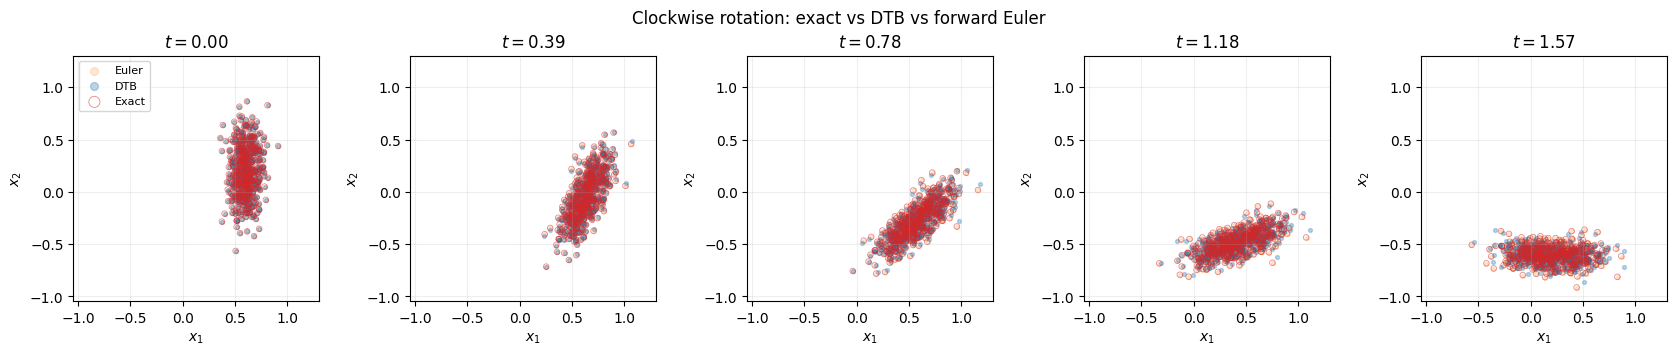

In [5]:
steps = sorted(snapshots)

# Use identical square limits at every time so changes in scale are meaningful.
all_points = torch.cat([cloud for triplet in snapshots.values() for cloud in triplet])
lo, hi = float(all_points.min()), float(all_points.max())
pad = 0.06 * (hi - lo)

fig, axes = plt.subplots(1, len(steps), figsize=(3.4 * len(steps), 3.4), squeeze=False)
for ax, k in zip(axes[0], steps):
    dtb_x, exact_x, euler_x = snapshots[k]
    # Draw exact last with red hollow markers so it stays visible in the overlay.
    ax.scatter(euler_x[:, 0], euler_x[:, 1], s=8, c="tab:orange", alpha=.18, label="Euler")
    ax.scatter(dtb_x[:, 0], dtb_x[:, 1], s=8, c="tab:blue", alpha=.30, label="DTB")
    ax.scatter(exact_x[:, 0], exact_x[:, 1], s=16, facecolors="none", edgecolors="tab:red",
               linewidths=.6, alpha=.55, label="Exact")
    ax.set(title=fr"$t={k*h:.2f}$", xlabel="$x_1$", ylabel="$x_2$",
           aspect="equal", xlim=(lo-pad, hi+pad), ylim=(lo-pad, hi+pad))
    ax.grid(alpha=.2)
axes[0, 0].legend(markerscale=2, fontsize=8)
fig.suptitle("Clockwise rotation: exact vs DTB vs forward Euler")
fig.tight_layout(); plt.show()

## Requested diagnostics

$r_{\rm proj}$ is the relative tangent projection residual. $E_{\rm radius}$, $E_{\rm phase}$, and $E_{\rm traj}$ are particle RMS errors. Duplicate samples at reset times show refit jumps directly; dashed lines mark every reset.

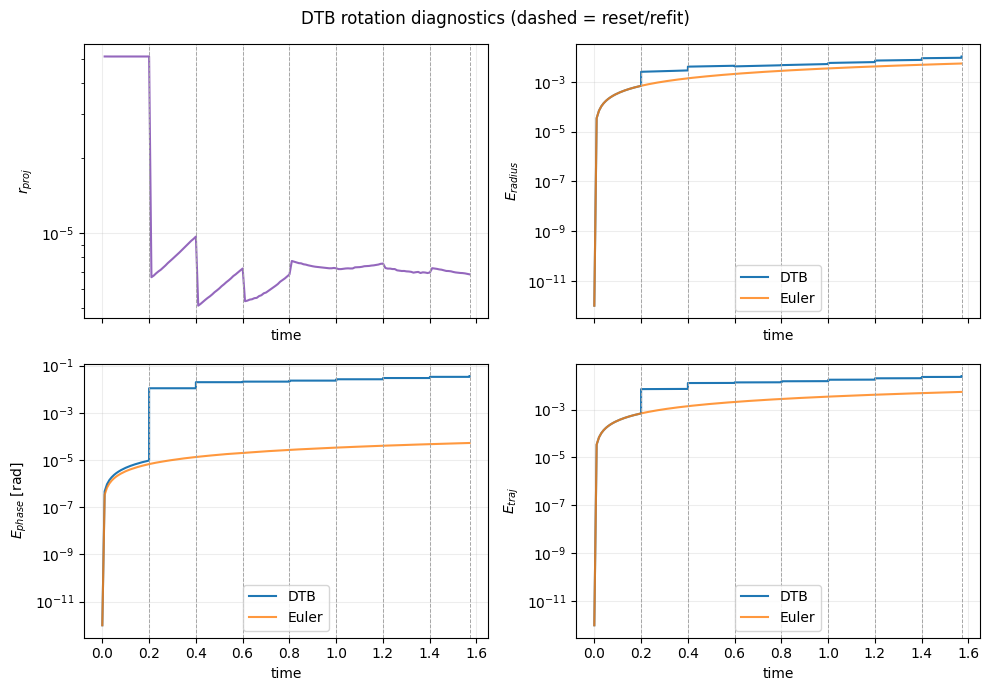

max projection residual: 5.116e-05
final DTB   radius/phase/trajectory: 1.041e-02, 3.584e-02, 2.484e-02
final Euler radius/phase/trajectory: 5.422e-03, 5.251e-05, 5.422e-03


In [6]:
t = np.asarray(metrics["t"]); proj = np.asarray(metrics["r_proj"], float)
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
mask = np.isfinite(proj) & (proj > 0)
axes[0, 0].semilogy(t[mask], proj[mask], color="tab:purple"); axes[0, 0].set_ylabel(r"$r_{proj}$")
for ax, key, label in ((axes[0, 1], "radius", r"$E_{radius}$"),
                            (axes[1, 0], "phase", r"$E_{phase}$ [rad]"),
                            (axes[1, 1], "traj", r"$E_{traj}$")):
    ax.semilogy(t, np.maximum(metrics[f"{key}_dtb"], 1e-12), label="DTB")
    ax.semilogy(t, np.maximum(metrics[f"{key}_euler"], 1e-12), label="Euler", alpha=.8)
    ax.set_ylabel(label); ax.legend()
for ax in axes.flat:
    for tr in reset_times: ax.axvline(tr, color=".65", lw=.7, ls="--")
    ax.grid(alpha=.22); ax.set_xlabel("time")
fig.suptitle("DTB rotation diagnostics (dashed = reset/refit)")
fig.tight_layout(); plt.show()

last = -1
print(f"max projection residual: {np.nanmax(proj):.3e}")
print(f"final DTB   radius/phase/trajectory: {metrics['radius_dtb'][last]:.3e}, "
      f"{metrics['phase_dtb'][last]:.3e}, {metrics['traj_dtb'][last]:.3e}")
print(f"final Euler radius/phase/trajectory: {metrics['radius_euler'][last]:.3e}, "
      f"{metrics['phase_euler'][last]:.3e}, {metrics['traj_euler'][last]:.3e}")